# `lambda_geo` 是怎么计算的

这个 notebook 用一个二维两带 Dirac toy model 演示 `graphene/tb/core.py` 里 `lambda_geo` 的计算逻辑。

目标不是复现完整石墨烯数值，而是把代码里的这一步看清楚：

$$
\lambda_{geo}
=
C
\oint_{FS} ds\,
\frac{\Delta E^2(k)\,\mathrm{Tr}\,g(k)}{|\nabla_k E(k)|}
$$

对应 `core.py::integrate_fermi_surface_observables()` 里的这一行：

```python
total_lambda_geo += np.sum(ds * safe_gap_sq * sampled["metric_trace"] / safe_velocity)
```

整个 notebook 会按 `learning-demo` 的顺序来讲：先说明问题对象，再写解析公式和离散公式，再写 toy model 代码，最后用图把几何对象、积分核、中间量和收敛过程画出来。


## 0. 问题对象

这段代码最终要算的不是完整的 $\lambda_{geo}$，而是它在乘上公共 prefactor 之前的费米线积分部分：

$$
\lambda_{geo,\mathrm{integral}}
=
\oint_{FS} ds\,

rac{\Delta E^2(k)\,\mathrm{Tr}\,g(k)}{|
abla_k E(k)|}
$$

这里面有 4 个最关键的对象：

- $FS$：费米线，也就是满足 $E_-(k)=\mu$ 的等能线
- $ds$：沿费米线的一小段弧长
- $\Delta E(k)$：上下两条能带的能量差
- $\mathrm{Tr}\,g(k)$：量子度规的迹
- $|
abla_k E(k)|$：下带能量沿 $k$ 空间的梯度大小

所以代码的核心任务可以拆成 3 步：

1. 先构造费米线
2. 再沿费米线每一小段取样中间量
3. 最后把这些小段贡献加起来

这个 notebook 里的 toy model 只保留这 3 步，不引入石墨烯真实模型里别的复杂结构。


## 1. toy model 和公式

我们用最简单的二维 massive Dirac 模型：

$$
H(q)=v q_x \sigma_x + v q_y \sigma_y + m \sigma_z
$$

它的下带能量是

$$
E_-(q) = -\sqrt{v^2 q^2 + m^2}
$$

当化学势满足 $\mu < -m$ 时，$E_-(q)=\mu$ 会给出一条圆形费米线。

在这个两带模型里，还要用到单位化的 $d$ 向量：

$$
\hat d(q)=\frac{d(q)}{|d(q)|}
$$

量子度规张量可以写成：

$$
g_{ij}(q)=\frac{1}{4}\,\partial_i \hat d(q) \cdot \partial_j \hat d(q)
$$

所以量子度规的迹就是：

$$
\mathrm{Tr}\,g(q)=g_{xx}(q)+g_{yy}(q)
=\frac{1}{4}\left[(\partial_{q_x}\hat d)\cdot(\partial_{q_x}\hat d)+(\partial_{q_y}\hat d)\cdot(\partial_{q_y}\hat d)\right]
$$

这正是后面 `metric_trace()` 函数在数值上实现的内容。代码里没有直接把 $\partial_{q_x}\hat d$ 和 $\partial_{q_y}\hat d$ 的解析式写出来，而是用中心差分去近似：

$$
\partial_{q_x}\hat d(q_x,q_y)
\approx
\frac{\hat d(q_x+h,q_y)-\hat d(q_x-h,q_y)}{2h}
$$

$$
\partial_{q_y}\hat d(q_x,q_y)
\approx
\frac{\hat d(q_x,q_y+h)-\hat d(q_x,q_y-h)}{2h}
$$

所以 `metric_trace()` 做的事情就是：先算 $\hat d$，再算两个方向的数值偏导，最后按上面的公式组装出 $\mathrm{Tr}\,g$。

为了和源码保持一致，我们要沿这条费米线逐段做三件事：

1. 计算相邻费米线点之间的小弧长 $ds$
2. 在每一小段中点处采样 $\Delta E(k)$、$\mathrm{Tr}\,g(k)$、$|\nabla_k E(k)|$
3. 把每一段的贡献

$$
ds\times \frac{\Delta E^2\,\mathrm{Tr}\,g}{|\nabla_k E|}
$$

累加起来


In [13]:
# 导入数值数组库，用来做向量、矩阵和离散求和。
import numpy as np
# 导入绘图库，用来把费米线、积分核和收敛过程画出来。
import matplotlib.pyplot as plt

# 设置默认图尺寸，保证 notebook 里的图不至于太小。
plt.rcParams["figure.figsize"] = (7, 5)
# 打开坐标网格，方便观察曲线和几何对象。
plt.rcParams["axes.grid"] = True

# 设置 Dirac 模型里的速度参数 v。
v = 1.0
# 设置质量项 mass，它控制 Dirac 点附近的小能隙。
mass = 0.12
# 设置化学势 mu；这里取负值，使费米线落在下能带上。
mu = -0.45
# 设置离散费米线时使用的角度点个数。
num_points = 360


In [14]:
def dirac_dvec(qx, qy, v=v, mass=mass):
    # 构造两带 Dirac 模型的 d 向量 d(q)。
    # 这里第一个分量是 v*qx，对应 x 方向的线性色散。
    # 这里第二个分量是 v*qy，对应 y 方向的线性色散。
    # 这里第三个分量是 mass，对应打开的微小质量项/能隙项。
    return np.array([v * qx, v * qy, mass], dtype=float)


def lower_band_energy(qx, qy, v=v, mass=mass):
    # 计算下能带 E_-(q)。
    # qx*qx + qy*qy 就是 q^2，也就是离 Dirac 点的径向距离平方。
    # v*v*(qx*qx + qy*qy) + mass*mass 对应 Dirac 色散关系根号内部。
    # 最前面的负号表示这里取的是 lower band，而不是 upper band。
    return -np.sqrt(v * v * (qx * qx + qy * qy) + mass * mass)


def gap_ev(qx, qy, v=v, mass=mass):
    # 计算上下两条能带之间的能隙 Delta E(q)。
    # 对这个两带模型，upper band 是 +sqrt(...)，lower band 是 -sqrt(...)。
    # 所以上下带的能量差就是 2*sqrt(...)
    return 2.0 * np.sqrt(v * v * (qx * qx + qy * qy) + mass * mass)


def velocity_norm(qx, qy, v=v, mass=mass):
    # 先计算 q 的大小，也就是当前点到 Dirac 点的径向距离。
    q = np.sqrt(qx * qx + qy * qy)
    # 这里计算 |E(q)|，也就是去掉正负号后的能量尺度。
    energy_abs = np.sqrt(v * v * q * q + mass * mass)
    # 返回 |grad_k E| 的解析表达式。
    # 对 E_-(q) = -sqrt(v^2 q^2 + m^2)，有 |grad E| = v^2 q / sqrt(v^2 q^2 + m^2)。
    return v * v * q / energy_abs


def metric_trace(qx, qy, v=v, mass=mass, h=1.0e-6):
    # 这个函数计算量子度规的迹 Tr g = g_xx + g_yy。
    # 对两带模型，可以用 g_ij = 1/4 * (∂_i d_hat)·(∂_j d_hat)。
    # 其中 d_hat = d / |d| 是单位化之后的 d 向量。
    # 这里不用解析式，而是直接用数值差分来算偏导。
    def d_hat(x, y):
        # 先得到当前位置的 d 向量。
        d = dirac_dvec(x, y, v=v, mass=mass)
        # 再把 d 单位化，得到 d_hat。
        return d / np.linalg.norm(d)

    # 用中心差分近似 ∂ d_hat / ∂qx。
    ddx = (d_hat(qx + h, qy) - d_hat(qx - h, qy)) / (2.0 * h)
    # 用中心差分近似 ∂ d_hat / ∂qy。
    ddy = (d_hat(qx, qy + h) - d_hat(qx, qy - h)) / (2.0 * h)
    # ddx @ ddx 表示 (∂_x d_hat)·(∂_x d_hat)。
    # ddy @ ddy 表示 (∂_y d_hat)·(∂_y d_hat)。
    # 最后乘 0.25，就是 Tr g 的两带模型公式。
    return 0.25 * (ddx @ ddx + ddy @ ddy)


## 2. 构造费米线折线 `segments`

这一步对应 graphene 代码里已经拿到 `segments_reduced` 之后的状态。

在 toy model 里，费米线是圆，所以我们直接用很多个角度点把它离散成一条闭合折线。

先由费米面条件

$$
E_-(q_F)=\mu
$$

求出费米半径 $q_F$。代入

$$
E_-(q) = -\sqrt{v^2 q^2 + m^2}
$$

可以得到

$$
q_F = \frac{\sqrt{\mu^2-m^2}}{v}
$$

这就是代码里

```python
q_fermi = np.sqrt(mu * mu - mass * mass) / v
```

的来源。

得到 $q_F$ 以后，圆形费米线可以参数化成：

$$
q_x(\theta)=q_F\cos\theta,
\qquad
q_y(\theta)=q_F\sin\theta,
\qquad
\theta\in[0,2\pi)
$$

这对应代码里的

```python
theta = np.linspace(0.0, 2.0 * np.pi, num_points, endpoint=False)
segments = np.column_stack([q_fermi * np.cos(theta), q_fermi * np.sin(theta)])
```

其中 `endpoint=False` 的意思是：取很多个角度点，但先不重复取 $2\pi$，因为 $2\pi$ 和 $0$ 是同一个方向。后面再手动把第一个点拼回最后一个点，构造闭合折线。

对于离散后的相邻两点 $q_i$ 和 $q_{i+1}$，每一小段的长度近似是

$$
ds_i \approx |q_{i+1}-q_i|
$$

这就是

```python
ds = np.linalg.norm(segments[1:] - segments[:-1], axis=1)
```

的来源。

为了在每一小段上采样物理量，代码还取了每一小段的中点：

$$
q_i^{\mathrm{mid}} = \frac{q_i+q_{i+1}}{2}
$$

这对应

```python
midpoints = 0.5 * (segments[:-1] + segments[1:])
```

然后在这些中点上分别计算：

$$
\Delta E(q_i^{\mathrm{mid}}),
\qquad
\mathrm{Tr}\,g(q_i^{\mathrm{mid}}),
\qquad
|\nabla_q E(q_i^{\mathrm{mid}})|
$$

于是连续的费米线积分

$$
\oint_{FS} ds\,\frac{\Delta E^2\,\mathrm{Tr}\,g}{|\nabla E|}
$$

就被离散成求和：

$$
\lambda_{geo,\mathrm{integral}}
\approx
\sum_i
ds_i\,
\frac{\Delta E^2(q_i^{\mathrm{mid}})\,\mathrm{Tr}\,g(q_i^{\mathrm{mid}})}{|\nabla_q E(q_i^{\mathrm{mid}})|}
$$

这就是后面代码里 `geo_kernel`、`segment_contribution` 和 `lambda_geo_integral` 的数学来源。


In [15]:
# 由费米面条件 E_-(q_F) = mu 反解出费米半径 q_F。
# 对 lower band，E_-(q) = -sqrt(v^2 q^2 + mass^2)。
# 所以 q_F = sqrt(mu^2 - mass^2) / v。
q_fermi = np.sqrt(mu * mu - mass * mass) / v
# 在 0 到 2pi 之间均匀取很多角度点，用来离散圆形费米线。
# endpoint=False 表示不把 2pi 这个重复端点算进去。
theta = np.linspace(0.0, 2.0 * np.pi, num_points, endpoint=False)

# 用圆的参数方程生成费米线上的离散点。
# 每一行都是一个二维坐标 (q_x, q_y)。
segments = np.column_stack([q_fermi * np.cos(theta), q_fermi * np.sin(theta)])
# 把第一个点再拼到最后，形成闭合折线。
# 这样后面计算最后一小段时就不会漏掉收尾连接。
segments = np.vstack([segments, segments[0]])

# 取每一小段的中点，后面就在这些中点上采样物理量。
midpoints = 0.5 * (segments[:-1] + segments[1:])
# 计算相邻折线点之间的距离，这就是离散线积分里的每一小段长度 ds。
ds = np.linalg.norm(segments[1:] - segments[:-1], axis=1)

# 在每个中点上计算能隙 Delta E(k)。
sample_gap = np.array([gap_ev(x, y) for x, y in midpoints])
# 在每个中点上计算量子度规的迹 Tr g(k)。
sample_metric = np.array([metric_trace(x, y) for x, y in midpoints])
# 在每个中点上计算速度大小 |grad E(k)|。
sample_velocity = np.array([velocity_norm(x, y) for x, y in midpoints])

# 构造 lambda_geo 的积分核：DeltaE^2 * Tr g / |grad E|。
# np.maximum(..., 1e-12) 是为了防止速度极小导致分母数值不稳定。
geo_kernel = sample_gap**2 * sample_metric / np.maximum(sample_velocity, 1.0e-12)
# 每一小段的真实贡献 = 小段长度 ds * 该点处的积分核。
segment_contribution = ds * geo_kernel
# 把所有小段贡献加起来，就得到离散版的费米线积分。
lambda_geo_integral = float(np.sum(segment_contribution))

# 输出费米半径 q_F，帮助确认费米线的几何大小。
print(f"q_F = {q_fermi:.6f}")
# 输出离散费米线积分结果，也就是还没乘公共 prefactor 的 lambda_geo 积分部分。
print(f"lambda_geo_integral = {lambda_geo_integral:.6f}")
# 输出平均每一小段的长度，帮助理解当前离散网格有多细。
print(f"mean(ds) = {ds.mean():.6e}")
# 输出积分核的平均值，帮助判断量级。
print(f"mean(kernel) = {geo_kernel.mean():.6f}")


q_F = 0.433705
lambda_geo_integral = 3.028479
mean(ds) = 7.569484e-03
mean(kernel) = 1.111363


## 3. 图 1：费米线上的积分核长什么样

左图把下带能量画成背景，并把费米线画出来。

彩色点表示每一小段中点处的积分核：

$$
\frac{\Delta E^2\,\mathrm{Tr}\,g}{|\nabla_k E|}
$$

右图把每一小段的真实贡献画出来：

$$
ds_i\times \frac{\Delta E_i^2\,\mathrm{Tr}\,g_i}{|\nabla_k E_i|}
$$


## 4. 图 2：把中间量单独拆开来看

上面的图已经把最终积分核

$$
\frac{\Delta E^2\,\mathrm{Tr}\,g}{|\nabla E|}
$$

画出来了，但如果只看最终组合量，还是不容易知道到底是哪一部分在起主要作用。

所以这里把 3 个中间量单独画出来：

$$
\Delta E(\theta),
\qquad
\mathrm{Tr}\,g(\theta),
\qquad
|\nabla E(\theta)|
$$

这样就能直接看到：代码不是“神秘地算出了一个 kernel”，而是先分别算出能隙、量子度规和速度，再把它们按公式组合起来。


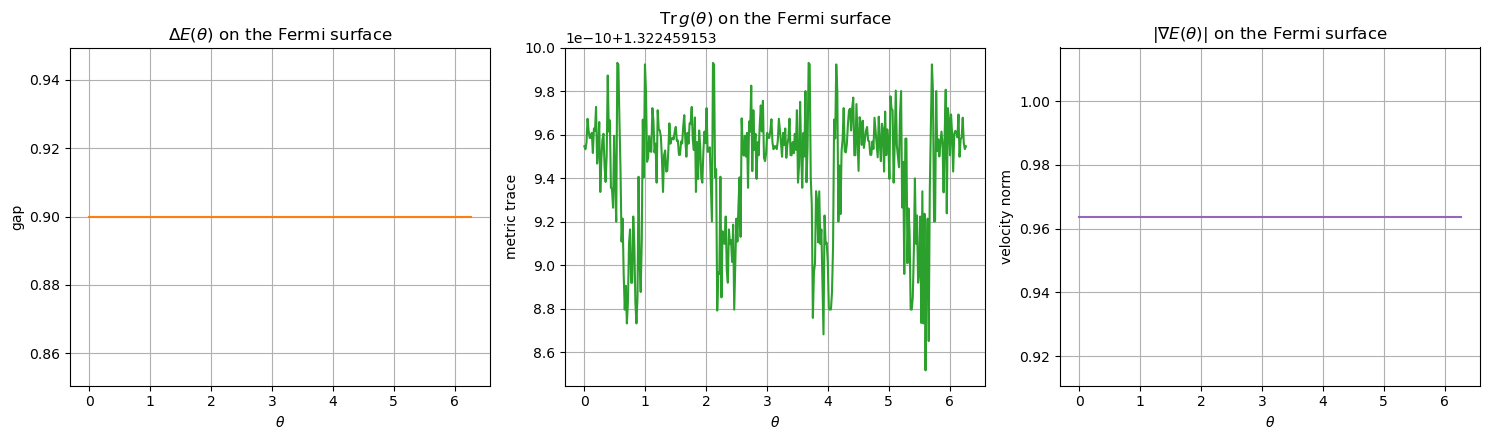

In [21]:
# 新建一个 1x3 的子图布局，分别画能隙、量子度规和速度。
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 取第一个子图，用来画能隙随角度的变化。
ax = axes[0]
# 画出 sample_gap，也就是每个中点上的 Delta E。
ax.plot(theta, sample_gap, color="tab:orange")
# 设置标题，明确这幅图画的是哪一个中间量。
ax.set_title(r"$\Delta E(\theta)$ on the Fermi surface")
# 标记横坐标是角度 theta。
ax.set_xlabel(r"$\theta$")
# 标记纵坐标是能隙大小。
ax.set_ylabel("gap")

# 取第二个子图，用来画量子度规迹随角度的变化。
ax = axes[1]
# 画出 sample_metric，也就是每个中点上的 Tr g。
ax.plot(theta, sample_metric, color="tab:green")
# 设置标题，明确这是量子度规迹。
ax.set_title(r"$\mathrm{Tr}\,g(\theta)$ on the Fermi surface")
# 标记横坐标是角度 theta。
ax.set_xlabel(r"$\theta$")
# 标记纵坐标是量子度规迹。
ax.set_ylabel("metric trace")

# 取第三个子图，用来画速度大小随角度的变化。
ax = axes[2]
# 画出 sample_velocity，也就是每个中点上的 |grad E|。
ax.plot(theta, sample_velocity, color="tab:purple")
# 设置标题，明确这是速度大小。
ax.set_title(r"$|\nabla E(\theta)|$ on the Fermi surface")
# 标记横坐标是角度 theta。
ax.set_xlabel(r"$\theta$")
# 标记纵坐标是速度大小。
ax.set_ylabel("velocity norm")

# 自动调整子图间距，避免标题和坐标轴重叠。
plt.tight_layout()


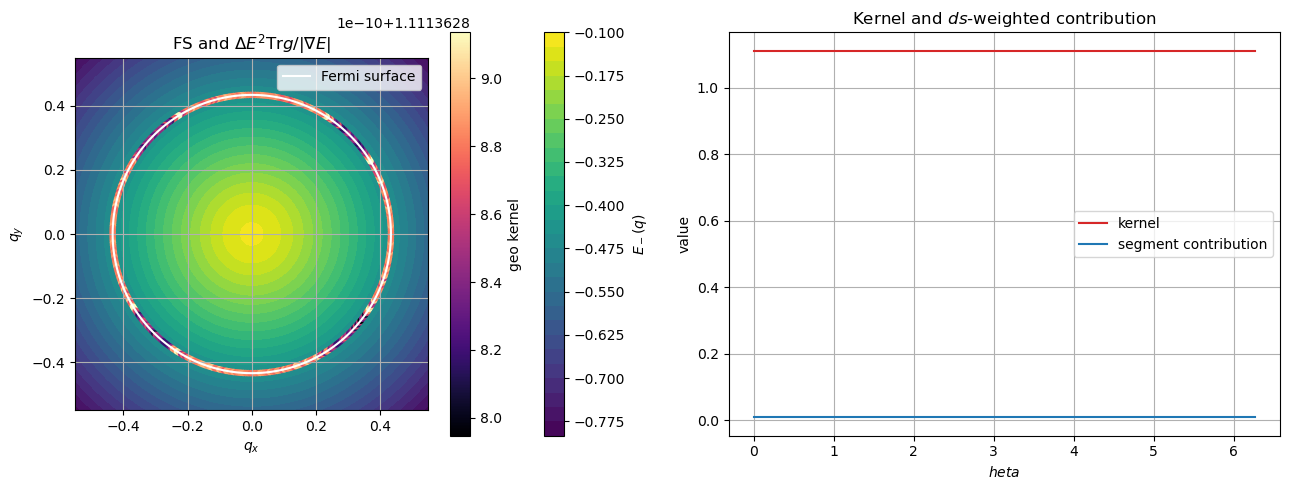

In [22]:
# 构造一个二维 q 空间网格，用来画下能带能量背景。
grid = np.linspace(-0.55, 0.55, 240)
# 把一维网格扩展成二维坐标网格。
qx_grid, qy_grid = np.meshgrid(grid, grid, indexing="xy")
# 在二维网格上计算下能带能量，作为背景标量场。
energy_grid = lower_band_energy(qx_grid, qy_grid)

# 新建一个 1x2 的子图布局。
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 取左边子图，用来画费米线在能量背景上的位置。
ax = axes[0]
# 用 contourf 画出下能带能量的填色背景。
im = ax.contourf(qx_grid, qy_grid, energy_grid, levels=30, cmap="viridis")
# 把离散费米线画成白色闭合曲线。
ax.plot(segments[:, 0], segments[:, 1], color="white", lw=1.5, label="Fermi surface")
# 把每段中点处的最终积分核用彩色散点画出来。
sc = ax.scatter(midpoints[:, 0], midpoints[:, 1], c=geo_kernel, s=14, cmap="magma")
# 设置标题，说明左图画的是费米线和几何积分核。
ax.set_title(r"FS and $\Delta E^2 \mathrm{Tr}g / |\nabla E|$")
# 标记横坐标为 q_x。
ax.set_xlabel("$q_x$")
# 标记纵坐标为 q_y。
ax.set_ylabel("$q_y$")
# 保持 x、y 比例一致，避免把圆画成椭圆。
ax.set_aspect("equal")
# 显示图例。
ax.legend(loc="upper right")
# 给背景能量图加 colorbar。
fig.colorbar(im, ax=ax, label="$E_-(q)$")
# 给积分核散点加 colorbar。
fig.colorbar(sc, ax=ax, label="geo kernel")

# 取右边子图，用来画沿费米线参数 theta 的一维分布。
ax = axes[1]
# 画出最终积分核 geo_kernel 随角度的变化。
ax.plot(theta, geo_kernel, label="kernel", color="tab:red")
# 画出每一段真实贡献 ds * kernel 随角度的变化。
ax.plot(theta, segment_contribution, label="segment contribution", color="tab:blue")
# 设置标题，说明右图比较的是积分核和 ds 加权后的贡献。
ax.set_title("Kernel and $ds$-weighted contribution")
# 标记横坐标是角度 theta。
ax.set_xlabel("$\theta$")
# 标记纵坐标是数值大小。
ax.set_ylabel("value")
# 显示图例。
ax.legend()

# 自动调整子图间距。
plt.tight_layout()


## 5. 图 3：把很多小段贡献累加起来

这里直接把源码里的求和写成：

$$
\lambda_{geo,\mathrm{integral}}
\approx
\sum_i
ds_i\,
\frac{\Delta E_i^2\,\mathrm{Tr}\,g_i}{|\nabla_k E_i|}
$$

随着段数增多，折线求和就逼近连续的费米线积分。


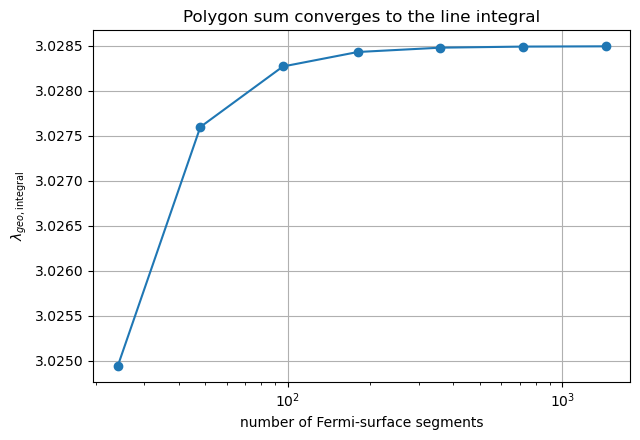

In [18]:
# 设置不同的离散段数，用来测试折线求和的收敛性。
mesh_list = [24, 48, 96, 180, 360, 720, 1440]
# 准备一个列表，用来存每种离散精度下得到的积分值。
integrals = []

# 依次遍历不同的离散段数。
for n in mesh_list:
    # 对当前段数重新生成角度离散点。
    th = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    # 用圆参数方程生成当前精度下的费米线折线点。
    seg = np.column_stack([q_fermi * np.cos(th), q_fermi * np.sin(th)])
    # 把第一个点再接到最后，形成闭合路径。
    seg = np.vstack([seg, seg[0]])
    # 计算每一小段的中点。
    mids = 0.5 * (seg[:-1] + seg[1:])
    # 计算每一小段的长度 ds。
    ds_local = np.linalg.norm(seg[1:] - seg[:-1], axis=1)
    # 在中点上计算局部能隙。
    gap_local = np.array([gap_ev(x, y) for x, y in mids])
    # 在中点上计算局部量子度规迹。
    metric_local = np.array([metric_trace(x, y) for x, y in mids])
    # 在中点上计算局部速度大小。
    vel_local = np.array([velocity_norm(x, y) for x, y in mids])
    # 按公式组合出局部积分核。
    kernel_local = gap_local**2 * metric_local / np.maximum(vel_local, 1.0e-12)
    # 把当前精度下的折线积分结果加进列表。
    integrals.append(float(np.sum(ds_local * kernel_local)))

# 新建一张图，用来画积分值随离散段数的变化。
plt.figure(figsize=(6.5, 4.5))
# 画出不同段数下的积分结果。
plt.plot(mesh_list, integrals, marker="o")
# 把横坐标设成对数尺度，更容易看清低段数到高段数的变化。
plt.xscale("log")
# 标记横坐标是费米线离散段数。
plt.xlabel("number of Fermi-surface segments")
# 标记纵坐标是离散积分结果。
plt.ylabel(r"$\lambda_{geo,\mathrm{integral}}$")
# 设置标题，强调这里观察的是折线求和向连续线积分的收敛。
plt.title("Polygon sum converges to the line integral")
# 自动调整图形边距。
plt.tight_layout()


## 6. 和 `core.py` 的一一对应

这个 demo 和源码的关键对应关系可以整理成一张表：

| 公式对象 | toy model 变量 | `core.py` 对象 | 物理意义 | 数值角色 |
|---|---|---|---|---|
| $FS$ | `segments` | `segments_reduced` | 费米线 | 离散积分路径 |
| $q_i^{\mathrm{mid}}$ | `midpoints` | `mid_reduced` | 每段中点 | 采样位置 |
| $ds_i$ | `ds` | `ds` | 线元长度 | 离散积分权重 |
| $\Delta E(q_i^{\mathrm{mid}})$ | `sample_gap` | `sampled["gap_ev"]` | 上下带能隙 | 积分核分子的一部分 |
| $\mathrm{Tr}\,g(q_i^{\mathrm{mid}})$ | `sample_metric` | `sampled["metric_trace"]` | 量子度规迹 | 积分核分子的一部分 |
| $\lvert \nabla E(q_i^{\mathrm{mid}})\rvert$ | `sample_velocity` | `sampled["velocity_norm"]` | 能带速度大小 | 积分核分母 |
| $\dfrac{\Delta E^2(q_i^{\mathrm{mid}})\,\mathrm{Tr}\,g(q_i^{\mathrm{mid}})}{\lvert \nabla E(q_i^{\mathrm{mid}})\rvert}$ | `geo_kernel` | `safe_gap_sq * sampled["metric_trace"] / safe_velocity` | 几何积分核 | 被积函数 |
| $ds_i\,\dfrac{\Delta E_i^2\,\mathrm{Tr}\,g_i}{\lvert \nabla E_i\rvert}$ | `segment_contribution` | 单段求和项 | 每段对总积分的贡献 | 离散求和项 |
| $\lambda_{geo,\mathrm{integral}}$ | `lambda_geo_integral` | `integrals["lambda_geo_integral"]` | 几何部分的费米线积分 | 最终离散结果 |

所以这段代码的本质就是：

1. 先找出费米线
2. 再把费米线切成很多小段
3. 在每一小段中点上计算能隙、量子度规和速度
4. 按公式组装局部积分核
5. 用 $ds$ 做权重，把所有小段贡献加起来
6. 最后再乘公共 prefactor，才变成真正输出的 $\lambda_{geo}$

## 7. 常见错误和检查点

如果这类代码结果不对，优先检查下面几项：

1. 费米线是不是取错了带，尤其是 lower band 和 upper band 是否混了。
2. `mu` 和 `mass` 是否满足 $|\mu| > m$，否则根本没有这条圆形费米线。
3. `segments` 是否真正闭合；如果没把第一个点接回最后一个点，就会漏掉最后一段。
4. `midpoints` 是否真的是中点；如果改成端点采样，离散误差会变大。
5. `metric_trace()` 里的差分步长 `h` 是否过大或过小；过大会不准，过小会受浮点误差影响。
6. `np.maximum(sample_velocity, 1.0e-12)` 这种速度分母保护是否保留；这个保护项对应源码里的 `safe_velocity`。
7. 收敛图是否稳定；如果段数增加后积分值还大幅漂移，说明离散精度不够或公式实现有错。

